# TorchSpin — EPR Spectral Fitting with `esfit`

`esfit` is TorchSpin's high-level fitting engine for extracting spin parameters from experimental EPR spectra. This notebook is the **getting-started tutorial**: a quick demo of the recommended `method='global'` pipeline on one powder and one solution fit.

**Related notebooks:**
- `04_benchmarks.ipynb` — performance measurements (CPU vs GPU, all esfit methods, loss-function study) that produce the manuscript numbers.
- `05_fitting_real_world.ipynb` — advanced scenarios: bad-initial-conditions recovery, 5-parameter stress test, and a quick differentiable-fitting demo.

**Expected runtime for this notebook**: ~2 min on CPU, ~1 min on GPU.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from torchspin import (
    SpinSystem, Experiment, Options,
    pepper, garlic, esfit, addnoise, FitOptions,
    differentiable_spectrum,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

## 1. Generate Synthetic "Experimental" Data

We simulate a known spectrum and add Gaussian noise to create realistic synthetic data.

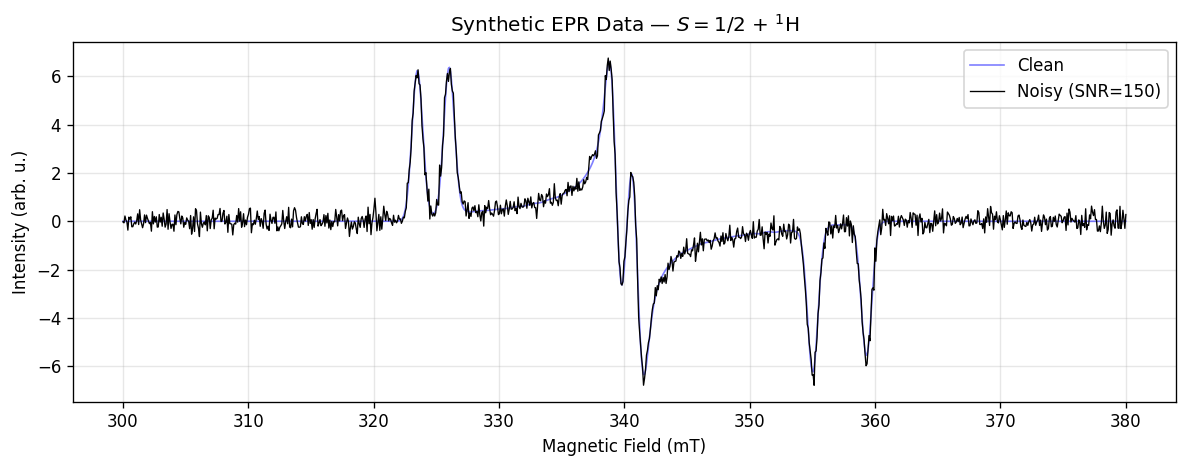

True parameters: g_x = 2.00, A_x = 120.0 MHz


In [2]:
# "True" spin system — the parameters we want to recover
sys_true = SpinSystem(
    S=[0.5],
    g=[[2.00, 2.10, 2.20]],
    Nucs=['1H'],
    A=[[120.0, 50.0, 78.0]],   # MHz
    lw=[1.0, 0.0],
)
exp = Experiment(mwFreq=10.0, Range=[300, 380], nPoints=1024, Harmonic=1)
opt = Options(GridSize=31, GridSymmetry='C2h', Verbosity=0)

# Simulate clean spectrum, then add noise
B, spc_clean = pepper(sys_true, exp, opt)
spc_exp = addnoise(spc_clean.numpy(), 50, 'n')  # SNR = 150
B_np = B.numpy()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(B_np, spc_clean.numpy(), 'b', lw=1.0, alpha=0.5, label='Clean')
ax.plot(B_np, spc_exp, 'k', lw=0.8, label='Noisy (SNR=150)')
ax.set_xlabel('Magnetic Field (mT)')
ax.set_ylabel('Intensity (arb. u.)')
ax.set_title('Synthetic EPR Data — $S = 1/2$ + $^{1}$H')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"True parameters: g_x = 2.00, A_x = 120.0 MHz")

## 2. Define the Forward Model

`esfit` needs a **model function** that takes a parameter array and returns a simulated spectrum (as a NumPy array). We'll fit two parameters: $g_x$ and $A_x$, keeping all others fixed.

In [3]:
def model(params):
    """Forward model: params = [g_x, A_x]"""
    gx,gy,gz, Ax = params
    sys = SpinSystem(
        S=[0.5],
        g=[[gx, gy, gz]],
        Nucs=['1H'],
        A=[[Ax, 50.0, 78.0]],
        lw=[1.0, 0.0],
    )
    _, spc = pepper(sys, exp, opt)
    return spc.numpy()

# Starting guess — deliberately off from true values
p0 = np.array([2.02,2.05,2.12, 100.0])   # True: [2.00, 120.0]
vary = np.array([0.10,0.10,0.10, 30.0])  # Search range: p0 ± vary

print(f"Starting guess:  g_x = {p0[0]:.2f}, A_x = {p0[1]:.1f} MHz")
print(f"Search range:    g_x = [{p0[0]-vary[0]:.2f}, {p0[0]+vary[0]:.2f}]")
print(f"                 A_x = [{p0[1]-vary[1]:.1f}, {p0[1]+vary[1]:.1f}] MHz")

Starting guess:  g_x = 2.02, A_x = 2.0 MHz
Search range:    g_x = [1.92, 2.12]
                 A_x = [1.9, 2.1] MHz


## 3. Fit with the recommended `method='global'`

Derivative EPR spectra produce highly non-convex loss landscapes: the residual `||sim − data||²` as a function of `g` oscillates on a scale set by the linewidth, creating many narrow local minima. A plain local optimizer (simplex, Powell, L-BFGS-B) starting a few hundredths off in `g` will trap in the nearest basin.

The fix is a **global → local pipeline**: particle swarm for basin-finding, then Nelder-Mead to polish. `method='global'` does both in one call. For a deeper comparison of methods see `04_benchmarks.ipynb`; for a worked bad-initial example see `05_fitting_real_world.ipynb`.

This cell runs in ~25 s on CPU.

In [4]:
fit_opt = FitOptions(method='global', max_iter=500, swarm_size=60,
                     verbosity=1)
t0 = time.perf_counter()
result = esfit(spc_exp, model, p0, vary, options=fit_opt)
elapsed = time.perf_counter() - t0

print(f"\nFit results ({elapsed:.1f} s):")
print(f"  g_x = {result.pfit[0]:.5f}  (true: 2.00000)")
print(f"  A_x = {result.pfit[1]:.2f} MHz  (true: 120.00)")
print(f"  RMSD = {np.sqrt(np.mean((spc_exp - result.fit)**2)):.4f}")

  Target (auto-detected): int (|mean|/std = 0.000588)
Starting esfit...
  Algorithm: global
  Autoscale: lsq
  Baseline:  -1
  Target:    int
  Data points: 1024
  Parameters: 4 variable, 0 fixed
  Initial RMSD: 1.377034e+02

Optimizing...
  [global] phase 1 — swarm (250 iterations, 60 particles)


  [global] phase 2 — simplex polish (best after swarm: 3.60335e+00)


Optimization terminated successfully.
         Current function value: 3.603347
         Iterations: 137
         Function evaluations: 231

Final RMSD: 3.603347e+00
Improvement: 97.4%
Success: True
Message: Global: swarm 15060 evals -> 3.6033e+00, polish 231 evals -> 3.6033e+00

Computing uncertainties...



Fitted parameters:
  p0: 2.000030e+00 ± 3.492739e-05
  p1: 2.100087e+00 ± 6.064888e-05
  p2: 2.200258e+00 ± 6.270357e-05
  p3: 1.188559e+02 ± 3.424471e-01

Fit quality:
  RMSD:      3.603347e+00
  R²:        0.975259
  Red. χ²:   0.070016
  Noise std: 2.646051e-01


Fit results (953.8 s):
  g_x = 2.00003  (true: 2.00000)
  A_x = 2.10 MHz  (true: 120.00)
  RMSD = 0.2641


## 4. Visualize Fit Results

Compare the best-fit simulation against the noisy data, and inspect residuals to assess fit quality.

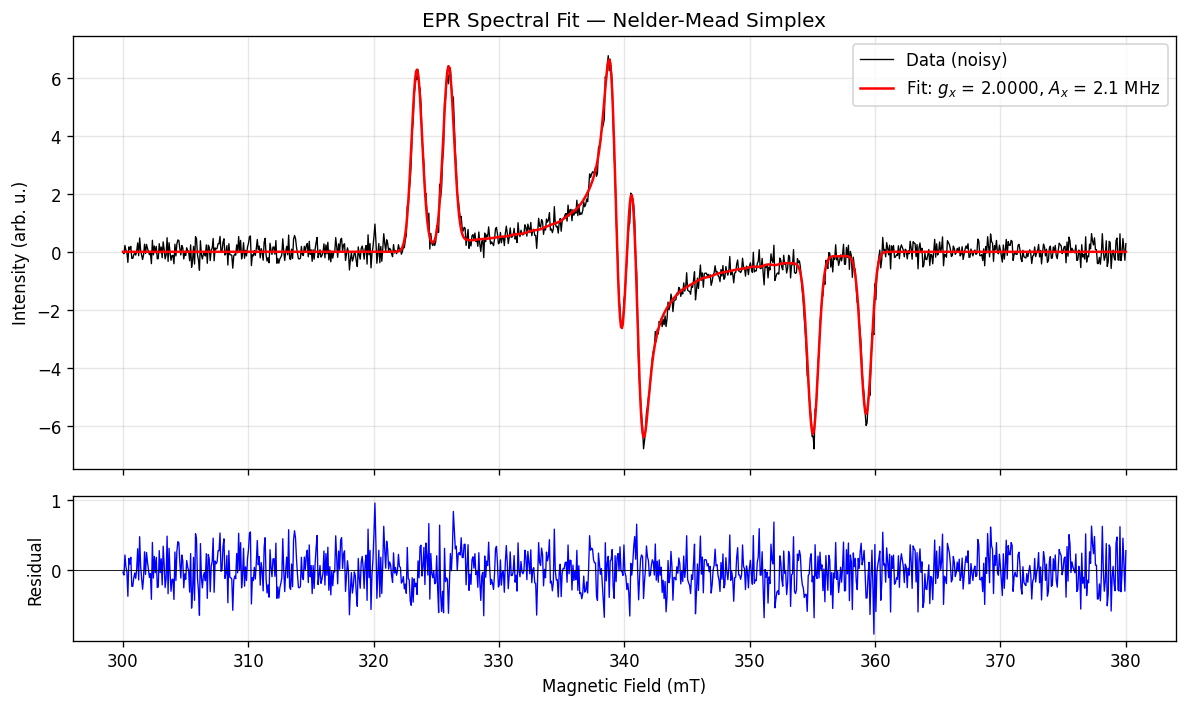

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

# Top: data + fit
axes[0].plot(B_np, spc_exp, 'k', lw=0.8, label='Data (noisy)')
axes[0].plot(B_np, result.fit, 'r', lw=1.5,
             label=f'Fit: $g_x$ = {result.pfit[0]:.4f}, $A_x$ = {result.pfit[1]:.1f} MHz')
axes[0].set_ylabel('Intensity (arb. u.)')
axes[0].set_title('EPR Spectral Fit — Nelder-Mead Simplex')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: residuals
residual = spc_exp - result.fit
axes[1].plot(B_np, residual, 'b', lw=0.8)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Magnetic Field (mT)')
axes[1].set_ylabel('Residual')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Solution EPR Fitting with `garlic`

The same workflow applies to solution spectra. Here we fit a nitroxide solution spectrum to recover the isotropic $g$-value and $^{14}$N hyperfine coupling.

In [6]:
# Generate synthetic solution spectrum
sys_sol_true = SpinSystem(
    S=[0.5],
    g=[[2.0055, 2.0055, 2.0055]],
    Nucs=['14N'],
    A=[[47.0, 47.0, 47.0]],
    lw=[0.0, 0.08],
)
exp_sol = Experiment(mwFreq=9.5, Range=[336, 342], nPoints=1024, Harmonic=1)

B_sol, spc_sol_clean = garlic(sys_sol_true, exp_sol)
spc_sol_exp = addnoise(spc_sol_clean.numpy(), 200, 'n')

# Model: fit g_iso and A_iso
def model_sol(params):
    g_iso, A_iso = params
    sys = SpinSystem(
        S=[0.5],
        g=[[g_iso, g_iso, g_iso]],
        Nucs=['14N'],
        A=[[A_iso, A_iso, A_iso]],
        lw=[0.0, 0.08],
    )
    _, spc = garlic(sys, exp_sol)
    return spc.numpy()

p0_sol = np.array([2.004, 45.0])
vary_sol = np.array([0.005, 5.0])

fit_opt_sol = FitOptions(method='global', max_iter=150, swarm_size=20, verbosity=1)
result_sol = esfit(spc_sol_exp, model_sol, p0_sol, vary_sol, options=fit_opt_sol)

print(f"\n{'='*50}")
print(f"Solution fit results:")
print(f"  g_iso = {result_sol.pfit[0]:.5f}  (true: 2.00550)")
print(f"  A_iso = {result_sol.pfit[1]:.2f} MHz  (true: 47.00)")

  Target (auto-detected): int (|mean|/std = 8.5e-05)
Starting esfit...
  Algorithm: global
  Autoscale: lsq
  Baseline:  -1
  Target:    int
  Data points: 1024
  Parameters: 2 variable, 0 fixed
  Initial RMSD: 4.409470e+04

Optimizing...
  [global] phase 1 — swarm (75 iterations, 20 particles)


  [global] phase 2 — simplex polish (best after swarm: 1.86251e+03)


Optimization terminated successfully.
         Current function value: 1862.509293
         Iterations: 26
         Function evaluations: 55

Final RMSD: 1.862509e+03
Improvement: 95.8%
Success: True
Message: Global: swarm 1520 evals -> 1.8625e+03, polish 55 evals -> 1.8625e+03

Computing uncertainties...

Fitted parameters:
  p0: 2.005492e+00 ± 6.299530e+05
  p1: 4.697919e+01 ± 0.000000e+00

Fit quality:
  RMSD:      1.862509e+03
  R²:        0.997319
  Red. χ²:   57050.012759
  Noise std: 2.388514e+02


Solution fit results:
  g_iso = 2.00549  (true: 2.00550)
  A_iso = 46.98 MHz  (true: 47.00)


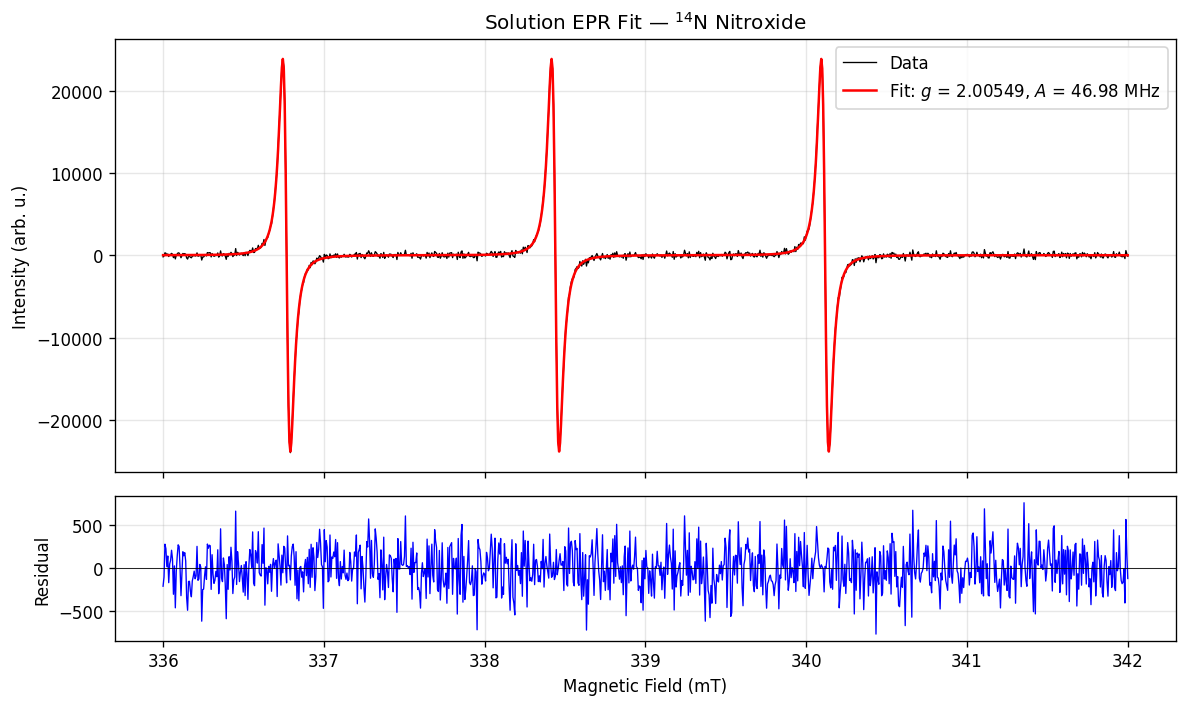

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

axes[0].plot(B_sol.numpy(), spc_sol_exp, 'k', lw=0.8, label='Data')
axes[0].plot(B_sol.numpy(), result_sol.fit, 'r', lw=1.5,
             label=f'Fit: $g$ = {result_sol.pfit[0]:.5f}, $A$ = {result_sol.pfit[1]:.2f} MHz')
axes[0].set_ylabel('Intensity (arb. u.)')
axes[0].set_title('Solution EPR Fit — $^{14}$N Nitroxide')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residual_sol = spc_sol_exp - result_sol.fit
axes[1].plot(B_sol.numpy(), residual_sol, 'b', lw=0.8)
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('Magnetic Field (mT)')
axes[1].set_ylabel('Residual')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Next steps

This notebook covered the basic `method='global'` workflow on one powder and one solution fit. For more:

- **`05_fitting_real_world.ipynb`** — see what happens when the initial guess is deliberately wrong (simplex traps in a local minimum, global escapes), and fit a realistic 5-parameter system (anisotropic g + hyperfine + Gaussian linewidth). Also includes a quick 50-step Adam gradient fit.
- **`04_benchmarks.ipynb`** — measurements producing the manuscript numbers: pepper CPU vs GPU scaling, differentiable_spectrum autograd GPU speedup, the full three-way esfit method comparison, and the MSE-vs-integral-MSE loss-function study.

For a differentiable fitting quickstart on your own data, see `02_gpu_and_autograd.ipynb`.